# **KNN Regressor**

## **Project:**

 - Restaurant Revenue Prediction

## **Problem Statement:**

- Predict restaurant revenue based on customer and location features. 

In [1]:
# Step No : 1 Importing Required Library 

# Import numerical Library
import numpy as np

# Import pandas library 
import pandas as pd 

# Import plotting library 
import matplotlib.pyplot as plt 

# Import Advanced visualization
import seaborn as sns 

# Import train test split 
from sklearn.model_selection import train_test_split

# Import KNN Regressor 
from sklearn.neighbors import KNeighborsRegressor

# Import Standard Scaler 
from sklearn.preprocessing import StandardScaler

# Import evaluation metrics 
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score



In [2]:
# Step No : 2 Loading dataset 
df = pd.read_csv("business_revenue_dataset.csv")

In [3]:
# Step No 3 : Understanding and analysing dataset 

# Display first rows 
print(df.head())

# Display Statistical summary 
print(df.describe())

# Display dataset information
print(df.info())

   Customers  AverageSpend  LocationScore  MarketingSpend  Revenue
0         50           200              7            5000    15000
1         60           220              8            6000    18000
2         70           250              9            7000    22000
3         80           270              8            7500    25000
4         90           300              9            8000    29000
        Customers  AverageSpend  LocationScore  MarketingSpend        Revenue
count   95.000000     95.000000      95.000000       95.000000      95.000000
mean   168.263158    491.526316       9.263158    11815.789474   60352.631579
std     70.160790    175.566066       0.788353     3618.107998   28286.986114
min     50.000000    200.000000       7.000000     5000.000000   15000.000000
25%    109.000000    342.500000       9.000000     8900.000000   35750.000000
50%    168.000000    485.000000       9.000000    11800.000000   59500.000000
75%    226.500000    632.500000      10.000000    14

In [4]:
# Step No 4 : Cleaning dataset 

# Check missing  values 
print(df.isnull().sum())

# Check duplicate rows 
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

Customers         0
AverageSpend      0
LocationScore     0
MarketingSpend    0
Revenue           0
dtype: int64
0


In [5]:
# Step No 5 : Features and Target Splitting
# Define input featrues 
X = df[[
    "Customers",
    "AverageSpend",
    "LocationScore",
    "MarketingSpend"
]]

# Define target variable 
y = df["Revenue"]

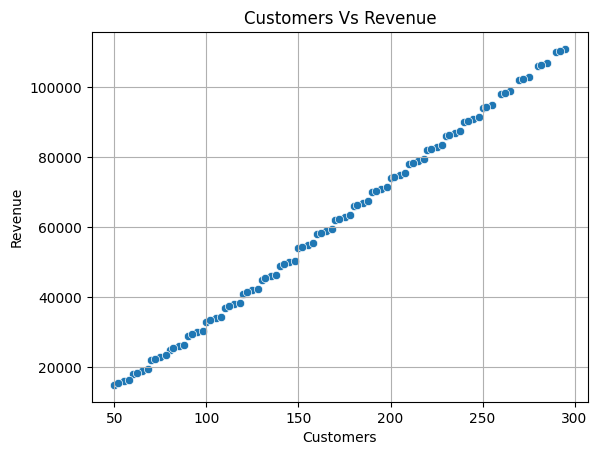

In [6]:
# Step No 6 : Visualization 
sns.scatterplot(x = "Customers" , y = "Revenue" , data = df)

# Set plot title 
plt.title("Customers Vs Revenue")

# Set x-axis label 
plt.xlabel("Customers")

# Set y-axix label 
plt.ylabel("Revenue")

# Enable grid 
plt.grid()

# Save figure
plt.savefig("images/Customers Vs Revenue(KNN Regressor ).png")

# Show Plt 
plt.show()

In [7]:
# Step No 7 : Split dataset 
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
# Step No 8 : Create Scaler Object 
scaler = StandardScaler()

# Scale  Training data 
X_train = scaler.fit_transform(X_train)

# Scale Testing Data 
X_test = scaler.transform(X_test)


In [9]:
# Step No 9 : Create KNN Regressor Model 
model = KNeighborsRegressor(
    n_neighbors= 5
)

In [10]:
# Step No 10 : Train model 
model.fit(X_train , y_train)

KNeighborsRegressor()

In [11]:
# Step No 11 : Predict Revenue 
y_pred = model.predict(X_test)

# Display Predicted values 
print("Predicted Revenue : ")
print(y_pred)

Predicted Revenue : 
[ 85400. 104000. 104000. 101700.  16900.  21300.  77700.  85700.  52900.
  94600.  51600.  36800.  40600. 104000.  59900.  27300.  82300.  23000.
  73700.]


In [12]:
# Step No 12 : Evaluate Metrices 
# Calculate MAE 
print("Mean Absolute Error : ")
print(mean_absolute_error(y_test , y_pred))

# Calculate MSE 
print("Mean Squared Error : ")
print(mean_squared_error(y_test , y_pred))

# Calculate RMSE
print("Root Mean Squared Error : ")
print(np.sqrt(mean_squared_error(y_test , y_pred)))

#Calculate R2 Score 
print("R2 Score : ")
print(r2_score(y_test , y_pred))

Mean Absolute Error : 
2168.4210526315787
Mean Squared Error : 
5796842.105263158
Root Mean Squared Error : 
2407.6632042840124
R2 Score : 
0.9937675511550369


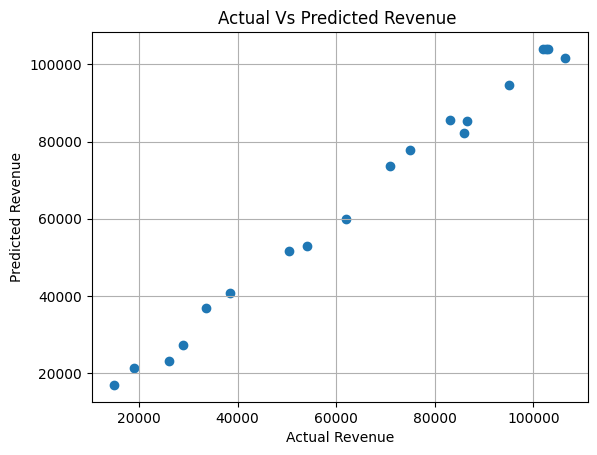

In [13]:
# Step No 13 : Plot actual Vs predicted(Visualization) 
plt.scatter(y_test , y_pred)

# Set Plot title 
plt.title("Actual Vs Predicted Revenue ")

# Set X-axis label 
plt.xlabel("Actual Revenue")

# Set Y-axis label 
plt.ylabel("Predicted Revenue")

# Enable Grid 
plt.grid()

# Save figure 
plt.savefig("images/Actual Vs Predicted Revenue(KNN Regressor).png")

# Display Plot 
plt.show()

In [14]:
# Step No 14 : User( Input 

# Take Customers Input 
customers = int(input("Enter Customers : "))

# Take average spend input 
average_spend = float(input("Enter Average Spend : "))

# Take location score input 
location_score = int(input("Enter Location Score : "))

# Take marketing spend input 
marketing_spend = float(input('Enter Marketing Spend : '))



In [15]:
# Step No 15 : Create User Input dataframe 
user_data = pd.DataFrame({
    "Customers": [customers],
    "AverageSpend": [average_spend],
    "LocationScore": [location_score],
    "MarketingSpend": [marketing_spend]
})

# Scale User Input 
user_data = scaler.transform(user_data)

In [16]:
# Predict user Revenue
result = model.predict(user_data)

In [17]:
# Step 16 : Display final output 
print(f"Predicted Restaurant Revenue is : ₹{result[0]:.2f}")

Predicted Restaurant Revenue is : ₹36800.00
